## Setup

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import requests

In [ ]:
url = 'https://stablecoins.llama.fi/stablecoins?includePrices=true'

data = requests.get(url).json()
stables = data['peggedAssets']

## total supply

In [3]:
df=pl.DataFrame(stables)

# Convert circulating column to numeric
df = df.with_columns(
    pl.col('circulating').struct.field('peggedUSD').alias('circulating_usd')
)

# Convert circulatingPrevDay column to numeric
df = df.with_columns(
    pl.col('circulatingPrevDay').struct.field('peggedUSD').alias('circulatingPrevDay_usd')
)

# Drop the original circulating and circulatingPrevDay columns
df = df.drop(['circulating', 'circulatingPrevDay'])

# Rename the new columns
df = df.rename({'circulating_usd': 'circulating', 'circulatingPrevDay_usd': 'circulatingPrevDay'})

# Sort the dataframe by circulating supply in descending order
df_sorted = df.sort(by='circulating', descending=True, nulls_last=True)

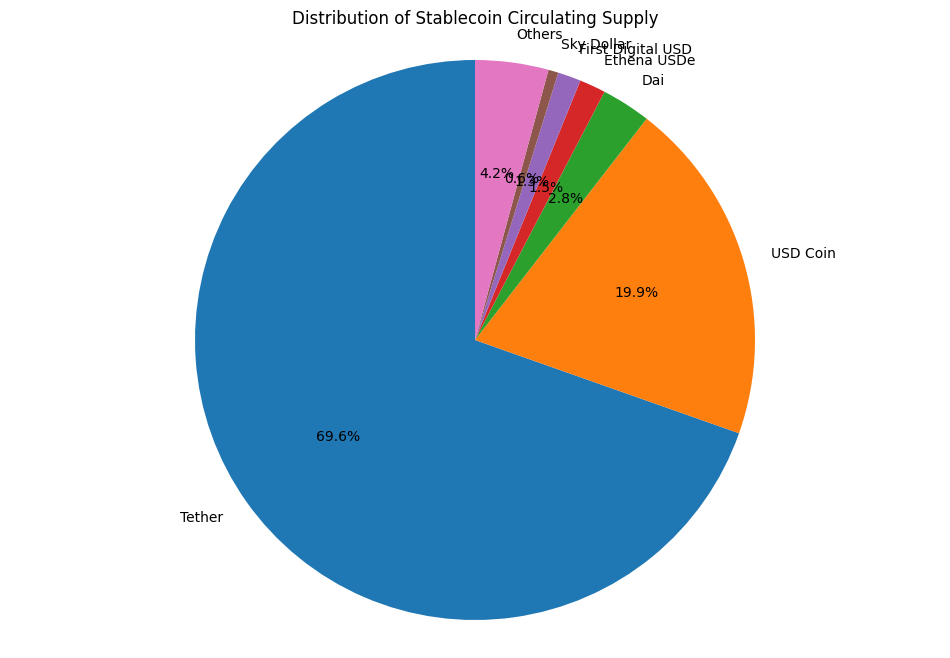

shape: (7, 2)
┌───────────────────┬─────────────┐
│ name              ┆ circulating │
│ ---               ┆ ---         │
│ str               ┆ f64         │
╞═══════════════════╪═════════════╡
│ Tether            ┆ 1.2032e11   │
│ USD Coin          ┆ 3.4407e10   │
│ Dai               ┆ 4.9219e9    │
│ Ethena USDe       ┆ 2.6207e9    │
│ First Digital USD ┆ 2.3061e9    │
│ Sky Dollar        ┆ 9.9811e8    │
│ Others            ┆ 7.3093e9    │
└───────────────────┴─────────────┘


In [4]:
# Get the top 4 stablecoins and sum the rest
top_4 = df_sorted.head(6)
others = df_sorted.tail(df_sorted.height - 6)
others_sum = others['circulating'].sum()

# Create a new dataframe for the pie chart, filtering out NaN values
pie_data = pl.concat([
    top_4.select('name', 'circulating').filter(pl.col('circulating').is_not_nan()),
    pl.DataFrame({'name': ['Others'], 'circulating': [others_sum]})
])

# Check if there are any valid data points
if pie_data.height > 0:
    # Create the pie chart
    plt.figure(figsize=(12, 8))
    plt.pie(pie_data['circulating'], labels=pie_data['name'], autopct='%1.1f%%', startangle=90)
    plt.title('Distribution of Stablecoin Circulating Supply')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    plt.show()
else:
    print("No valid data points for the pie chart.")

print(pie_data)